# DA4131 - Advanced ML Applications for Business
## Buy, Sell or Hold? Market Outlook May 2026
**Stocks:** GOOG, AAPL, MSFT  
**Group No:** 12 (226044G / 226067E / 226133E)

This notebook covers all tasks of Section 01 (Tasks 1 to 5). It trains one LSTM model per stock, evaluates it on a held-out test period, and produces a blind forecast for 1 to 14 May 2026.

**Main design decision:** the models predict the **daily log return**, not the raw price. Section 2.4 shows with an ADF test that prices are non-stationary while returns are stationary. A model trained on raw prices cannot predict above the highest price it saw in training, which is a serious problem when a stock reaches new highs.

**How to run:** run all cells from top to bottom. The grid search trains 36 small models, so allow some time (a GPU runtime in Colab helps).

In [1]:
# Install packages (most are already installed in Google Colab)
!pip install -q yfinance statsmodels plotly joblib scikit-learn tensorflow

In [2]:
import os, random, itertools, warnings
import numpy as np
import pandas as pd
import joblib
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

# ---- Global settings ----
TICKERS = ["GOOG", "AAPL", "MSFT"]
SEQ_LEN = 60          # look-back window (trading days)
TEST_RATIO = 0.2      # last 20% of the data is the test set
SEED = 42

def set_seed(seed=SEED):
    """Make results repeatable."""
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed()
print("Libraries imported. TensorFlow version:", tf.__version__)

Libraries imported. TensorFlow version: 2.21.0


## Task 1 - Preparing Data

Five years of daily data are downloaded with Python (`yfinance`). The last day is **31 March 2026**. Yahoo Finance treats the `end` date as exclusive, so `end='2026-04-01'` gives data up to 31 March.

Columns kept: Open, High, Low, Close, Volume. Prices are adjusted for splits and dividends (`auto_adjust=True`).

In [3]:
START_DATE = "2021-04-01"
END_DATE = "2026-04-01"      # exclusive -> last row is 2026-03-31

def download(ticker, start, end):
    """Download daily OHLCV data and return a clean DataFrame with a Date index."""
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    # Newer yfinance versions return two-level column names, so keep the price level only
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    df.index.name = "Date"
    return df

for t in TICKERS:
    df = download(t, START_DATE, END_DATE)
    df.to_csv(f"{t}_data.csv")
    print(f"{t}: {df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()} -> saved {t}_data.csv")
    display(df.head(3))

GOOG: 1255 rows, 2021-04-01 to 2026-03-31 -> saved GOOG_data.csv


Price,Open,High,Low,Close,Volume
Date,,,,,
2021-04-01,103.913264,106.141661,103.860760,105.884590,33980000
2021-04-05,106.636977,110.815894,106.571594,110.233406,43298000
2021-04-06,110.082354,110.833246,109.700965,110.193802,27060000


AAPL: 1255 rows, 2021-04-01 to 2026-03-31 -> saved AAPL_data.csv


Price,Open,High,Low,Close,Volume
Date,,,,,
2021-04-01,120.229723,120.735296,119.092173,119.588028,75089100
2021-04-05,120.433898,122.660375,119.656086,122.407585,88651200
2021-04-06,122.990941,123.603462,122.164521,122.708984,80171300


MSFT: 1255 rows, 2021-04-01 to 2026-03-31 -> saved MSFT_data.csv


Price,Open,High,Low,Close,Volume
Date,,,,,
2021-04-01,227.902633,232.078980,227.501246,231.610703,30338000
2021-04-05,232.002503,238.883459,231.945164,238.032898,36910600
2021-04-06,236.637619,238.348292,235.939972,236.876541,22931900


## Task 2 - EDA and Data Preprocessing

### 2.1 Load the saved CSV files and check data quality

In [4]:
data = {}
for t in TICKERS:
    df = pd.read_csv(f"{t}_data.csv", index_col="Date", parse_dates=True)
    assert df.index.is_monotonic_increasing, "dates must be in order"
    data[t] = df
    print(f"{t}: rows={len(df)}, missing values={int(df.isna().sum().sum())}, "
          f"duplicate dates={int(df.index.duplicated().sum())}, "
          f"range={df.index.min().date()} to {df.index.max().date()}")

display(pd.concat({t: data[t].describe().T for t in TICKERS}).round(2))

GOOG: rows=1255, missing values=0, duplicate dates=0, range=2021-04-01 to 2026-03-31
AAPL: rows=1255, missing values=0, duplicate dates=0, range=2021-04-01 to 2026-03-31
MSFT: rows=1255, missing values=0, duplicate dates=0, range=2021-04-01 to 2026-03-31


count         mean          std          min          25%  \
GOOG Open    1255.0       156.77        56.96        84.71       119.83   
     High    1255.0       158.60        57.61        85.74       121.07   
     Low     1255.0       155.06        56.21        82.67       118.95   
     Close   1255.0       156.87        56.96        82.71       119.82   
     Volume  1255.0  24077657.13  10139339.12   6138200.00  17558650.00   
AAPL Open    1255.0       185.44        41.62       119.95       149.59   
     High    1255.0       187.44        41.91       120.74       151.53   
     Low     1255.0       183.63        41.28       119.06       147.80   
     Close   1255.0       185.61        41.59       119.57       149.81   
     Volume  1255.0  66791146.45  28325000.86  17910600.00  46977100.00   
MSFT Open    1255.0       350.02        86.44       210.54       273.49   
     High    1255.0       353.21        86.68       213.31       276.35   
     Low     1255.0       346.61        85.93       206.55       269.89   
     Close   1255.0       350.03        86.29       207.34       272.94   
     Volume  1255.0  25826626.77  10693485.56   5855900.00  18941150.00   

                     50%          75%           max  
GOOG Open         140.26       173.32  3.478300e+02  
     High         141.56       175.12  3.494700e+02  
     Low          139.06       171.50  3.379300e+02  
     Close        140.32       173.13  3.442300e+02  
     Volume  21740200.00  27386700.00  9.779860e+07  
AAPL Open         175.29       219.64  2.854200e+02  
     High         177.23       222.40  2.878400e+02  
     Low          173.98       217.84  2.825300e+02  
     Close        175.53       220.08  2.854100e+02  
     Volume  60108400.00  79777000.00  3.186799e+08  
MSFT Open         329.32       415.11  5.498000e+02  
     High         332.39       418.32  5.500100e+02  
     Low          326.60       410.80  5.363600e+02  
     Close        329.56       414.32  5.376500e+02  
     Volume  23277700.00  29695550.00  1.288553e+08

### 2.2 Price performance
The first chart shows raw prices. The second rebases every stock to 100 on the first day so that the stocks can be compared fairly.

In [5]:
fig = go.Figure()
for t in TICKERS:
    fig.add_trace(go.Scatter(x=data[t].index, y=data[t]["Close"], mode="lines", name=t))
fig.update_layout(title="Closing prices, Apr 2021 to 31 Mar 2026",
                  xaxis_title="Date", yaxis_title="Close price (USD)")
fig.show()

fig = go.Figure()
for t in TICKERS:
    c = data[t]["Close"]
    fig.add_trace(go.Scatter(x=c.index, y=c / c.iloc[0] * 100, mode="lines", name=t))
fig.update_layout(title="Relative performance (first day = 100)",
                  xaxis_title="Date", yaxis_title="Index")
fig.show()

In [6]:
# Candlestick chart with trading volume underneath
for t in TICKERS:
    df = data[t]
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        row_heights=[0.75, 0.25], vertical_spacing=0.03)
    fig.add_trace(go.Candlestick(x=df.index, open=df["Open"], high=df["High"],
                                 low=df["Low"], close=df["Close"], name=t), row=1, col=1)
    fig.add_trace(go.Bar(x=df.index, y=df["Volume"], name="Volume"), row=2, col=1)
    fig.update_layout(title=f"{t} - candlestick chart and volume",
                      xaxis_rangeslider_visible=False, height=600)
    fig.show()

### 2.3 Returns and volatility
Daily log return = ln(Close today / Close yesterday). Returns show how risky each stock is and are the target of our model.

In [7]:
returns = {t: np.log(data[t]["Close"] / data[t]["Close"].shift(1)).dropna() for t in TICKERS}

stats = pd.DataFrame({
    t: {"Mean daily (%)": r.mean() * 100,
        "Std daily (%)": r.std() * 100,
        "Annualised volatility (%)": r.std() * np.sqrt(252) * 100,
        "Skewness": r.skew(),
        "Excess kurtosis": r.kurt(),
        "Worst day (%)": r.min() * 100,
        "Best day (%)": r.max() * 100}
    for t, r in returns.items()}).T.round(3)
display(stats)

fig = go.Figure()
for t in TICKERS:
    fig.add_trace(go.Histogram(x=returns[t] * 100, name=t, opacity=0.6, nbinsx=80))
fig.update_layout(barmode="overlay", title="Distribution of daily returns (%)",
                  xaxis_title="Daily return (%)", yaxis_title="Count")
fig.show()

fig = go.Figure()
for t in TICKERS:
    vol = returns[t].rolling(30).std() * np.sqrt(252) * 100
    fig.add_trace(go.Scatter(x=vol.index, y=vol, mode="lines", name=t))
fig.update_layout(title="Rolling 30-day annualised volatility (%)",
                  xaxis_title="Date", yaxis_title="Volatility (%)")
fig.show()

,Mean daily (%),Std daily (%),Annualised volatility (%),Skewness,Excess kurtosis,Worst day (%),Best day (%)
GOOG,0.079,1.932,30.670,-0.082,3.321,-10.131,9.499
AAPL,0.060,1.725,27.376,0.248,5.945,-9.701,14.262
MSFT,0.037,1.649,26.178,-0.127,3.989,-10.528,9.652


In [8]:
# Moving averages show the trend direction
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, subplot_titles=TICKERS, vertical_spacing=0.06)
for i, t in enumerate(TICKERS, start=1):
    c = data[t]["Close"]
    fig.add_trace(go.Scatter(x=c.index, y=c, name=f"{t} Close", line=dict(width=1)), row=i, col=1)
    fig.add_trace(go.Scatter(x=c.index, y=c.rolling(50).mean(), name=f"{t} 50-day MA"), row=i, col=1)
    fig.add_trace(go.Scatter(x=c.index, y=c.rolling(200).mean(), name=f"{t} 200-day MA"), row=i, col=1)
fig.update_layout(title="Closing price with 50-day and 200-day moving averages", height=900)
fig.show()

In [9]:
# Correlation of daily returns between the three stocks
ret_df = pd.DataFrame(returns)
fig = px.imshow(ret_df.corr(), text_auto=".2f", color_continuous_scale="RdBu",
                zmin=-1, zmax=1, title="Correlation of daily returns")
fig.show()

# Correlation between the OHLCV columns of each stock
for t in TICKERS:
    fig = px.imshow(data[t].corr(), text_auto=".2f", color_continuous_scale="RdBu",
                    zmin=-1, zmax=1, title=f"{t} - correlation between price and volume columns")
    fig.show()

### 2.4 Decomposition and stationarity test
The ADF test has the null hypothesis "the series has a unit root (non-stationary)". A p-value below 0.05 means the series is stationary.

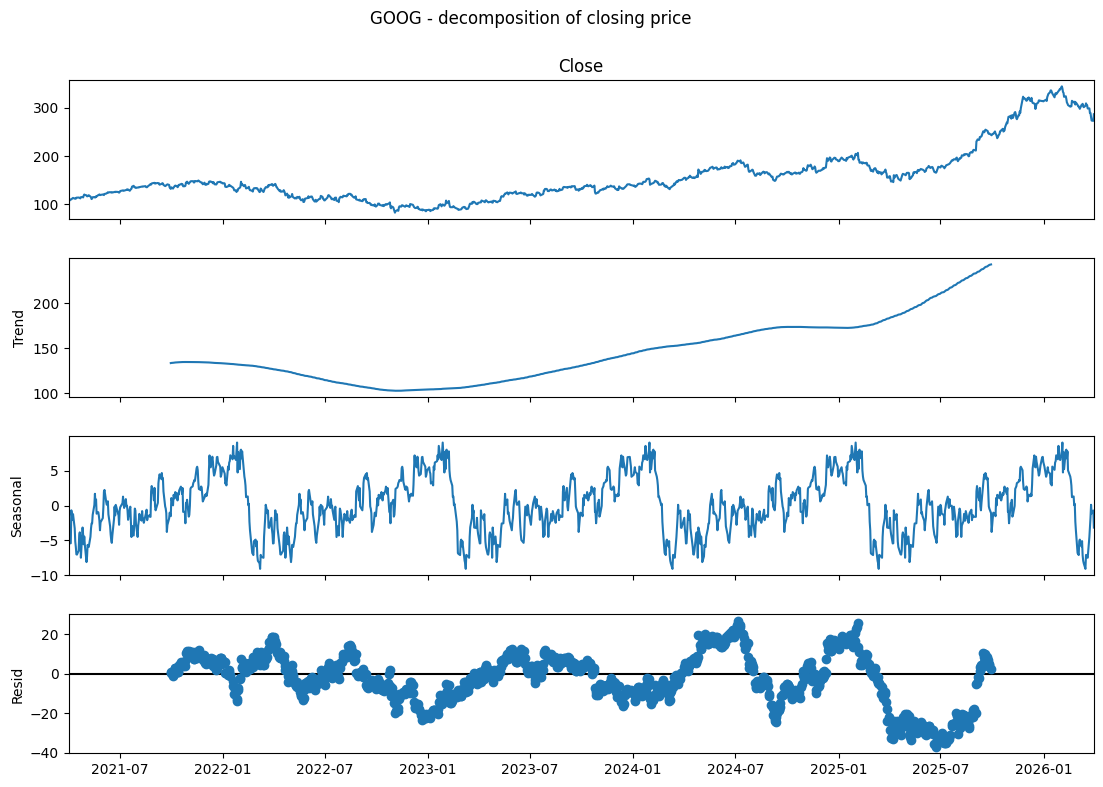

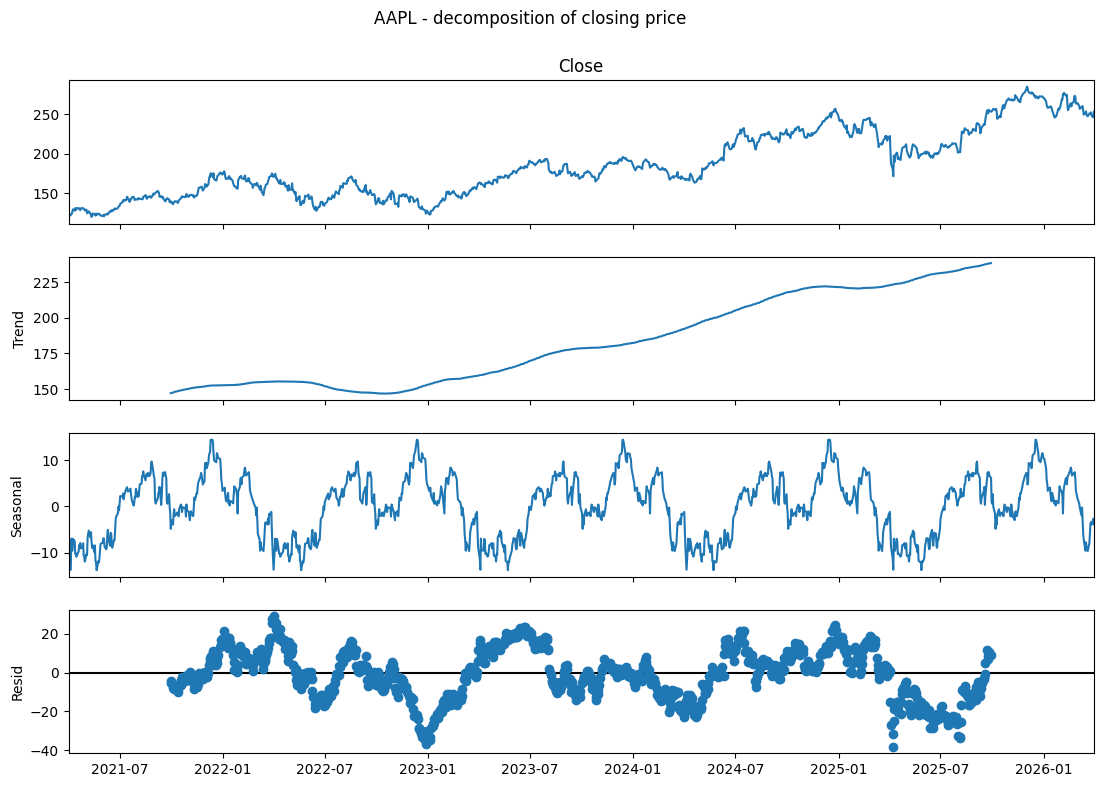

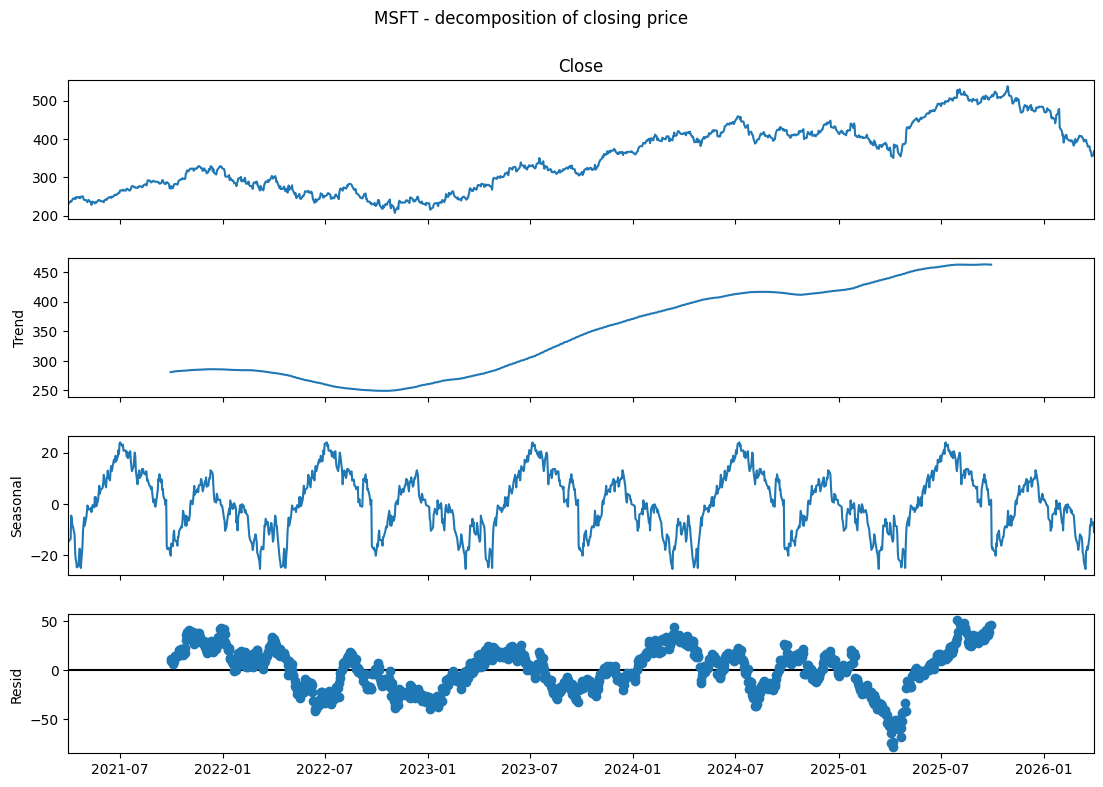

,Stock,Series,ADF statistic,p-value,Stationary (p < 0.05)
0,GOOG,Close price,0.213,0.9730,False
1,GOOG,Daily log return,-35.355,0.0000,True
2,AAPL,Close price,-1.346,0.6078,False
3,AAPL,Daily log return,-34.540,0.0000,True
4,MSFT,Close price,-1.541,0.5133,False
5,MSFT,Daily log return,-22.237,0.0000,True


In [10]:
adf_rows = []
for t in TICKERS:
    close = data[t]["Close"]
    dec = seasonal_decompose(close, model="additive", period=252)   # about 252 trading days per year
    fig = dec.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"{t} - decomposition of closing price", y=1.01)
    plt.show()

    for name, series in [("Close price", close), ("Daily log return", returns[t])]:
        stat, p = adfuller(series.dropna())[:2]
        adf_rows.append({"Stock": t, "Series": name, "ADF statistic": round(stat, 3),
                         "p-value": round(p, 4), "Stationary (p < 0.05)": p < 0.05})
display(pd.DataFrame(adf_rows))

**Reading the result:** the decomposition shows a strong trend in every stock, and the ADF test shows the price series are non-stationary while the return series are stationary. This is the main reason why the LSTM is trained on returns. Returns stay in a stable range, so the model does not need to predict prices outside the range it saw in training.

### 2.5 Special movements
The table lists the five largest daily moves in the five-year data. The volume ratio compares that day's volume with the average of the previous 20 days. A large move together with a high volume ratio usually means a news event, such as earnings.

In [11]:
rows = []
for t in TICKERS:
    df = data[t].copy()
    df["Return %"] = df["Close"].pct_change() * 100
    df["Vol ratio"] = df["Volume"] / df["Volume"].rolling(20).mean().shift(1)
    for d in df["Return %"].abs().nlargest(5).index:
        rows.append({"Stock": t, "Date": d.date(), "Return %": round(df.loc[d, "Return %"], 2),
                     "Close": round(df.loc[d, "Close"], 2), "Volume / 20-day avg": round(df.loc[d, "Vol ratio"], 2)})
display(pd.DataFrame(rows).sort_values(["Stock", "Date"]).reset_index(drop=True))

,Stock,Date,Return %,Close,Volume / 20-day avg
0,AAPL,2022-10-28,7.56,152.76,1.90
1,AAPL,2022-11-10,8.90,144.29,1.27
2,AAPL,2025-04-03,-9.25,201.95,1.99
3,AAPL,2025-04-04,-7.29,187.23,2.29
4,AAPL,2025-04-09,15.33,197.63,2.81
5,GOOG,2022-10-26,-9.64,93.93,3.07
6,GOOG,2023-10-25,-9.60,125.48,2.94
7,GOOG,2024-04-26,9.97,172.06,2.92
8,GOOG,2025-04-09,9.88,160.30,1.84
9,GOOG,2025-09-03,9.01,230.29,3.78


### 2.6 April 2026 review (for the Section 02 report)
These data are **not used for training**. They are downloaded only to find the sudden price changes in April 2026 that must be explained in the report. For each large move, search the news for that date (earnings, guidance, product or leadership news).

In [12]:
april = {}
for t in TICKERS:
    a = download(t, "2026-03-25", "2026-05-01")      # a few March days give the first April return
    if a.empty:
        print(f"{t}: no data returned")
        continue
    a["Return %"] = a["Close"].pct_change() * 100
    a["Volume / 60-day avg"] = a["Volume"] / data[t]["Volume"].tail(60).mean()
    a = a.loc["2026-04-01":]
    april[t] = a

    first, last = a["Close"].iloc[0], a["Close"].iloc[-1]
    print(f"{t}: April close {first:.2f} -> {last:.2f} ({(last / first - 1) * 100:+.1f}%), last date {a.index[-1].date()}")
    top = a["Return %"].abs().nlargest(3).index
    display(a.loc[sorted(top), ["Close", "Return %", "Volume / 60-day avg"]].round(2))

    fig = go.Figure(go.Scatter(x=a.index, y=a["Close"], mode="lines+markers", name=t))
    for d in top:
        fig.add_annotation(x=d, y=a.loc[d, "Close"], text=f"{a.loc[d, 'Return %']:+.1f}%",
                           showarrow=True, arrowhead=2)
    fig.update_layout(title=f"{t} - April 2026 closing price with the three largest daily moves",
                      xaxis_title="Date", yaxis_title="Close price (USD)")
    fig.show()

GOOG: April close 294.53 -> 381.46 (+29.5%), last date 2026-04-30


Price,Close,Return %,Volume / 60-day avg
Date,,,
2026-04-08,314.35,3.56,0.93
2026-04-14,330.17,3.56,0.83
2026-04-30,381.46,9.97,1.99


AAPL: April close 255.17 -> 270.87 (+6.1%), last date 2026-04-30


Price,Close,Return %,Volume / 60-day avg
Date,,,
2026-04-15,265.96,2.94,1.04
2026-04-17,269.75,2.59,1.27
2026-04-22,272.68,2.63,0.90


MSFT: April close 367.88 -> 406.13 (+10.4%), last date 2026-04-30


Price,Close,Return %,Volume / 60-day avg
Date,,,
2026-04-15,409.56,4.61,1.23
2026-04-23,414.07,-3.97,1.04
2026-04-30,406.13,-3.93,1.93


### 2.7 Preprocessing steps and justification

| Step | What we do | Why |
|---|---|---|
| 1. Cleaning | Flatten the two-level yfinance column names, set `Date` as a sorted datetime index, check for missing values and duplicates | The model needs a clean, ordered time series. The quality checks in 2.1 found no problems to repair. |
| 2. Log returns | Convert Close to daily log returns | The ADF test (2.4) shows prices are non-stationary and trend upward. A neural network trained on raw prices cannot predict values above its training range. Returns are stationary and comparable across stocks. |
| 3. Standardisation | `StandardScaler` fitted **on the training period only**, then applied to the test period | LSTMs train better on inputs with mean 0 and standard deviation 1. Fitting on training data only avoids data leakage from the test period. |
| 4. Sliding window | 60 past returns predict the next day return | About three months of trading history, a common choice in the literature. It captures short and medium term patterns without making training too slow. |
| 5. Chronological split | First 80% of days for training, last 20% for testing, no shuffling | This copies real use: train on the past, test on the future. The first test windows use the last 60 training returns as input only. No test target is seen in training. |
| 6. Outliers | Kept | Large moves (earnings, news) are real market behaviour and are exactly what an investor needs to understand. Standardisation and the Huber loss (Task 3) reduce their influence without deleting them. |
| 7. Features | Only the return of the Close price | Open, High, Low and Close are almost perfectly correlated (see the heatmaps), so extra price columns add little new information. |

In [13]:
def build_sequences(scaled, seq_len):
    """Window i uses scaled[i-seq_len : i] as input and scaled[i] as the target."""
    X, y = [], []
    for i in range(seq_len, len(scaled)):
        X.append(scaled[i - seq_len:i])
        y.append(scaled[i])
    return np.array(X), np.array(y)

prep = {}
for t in TICKERS:
    close = data[t]["Close"]
    rets = np.log(close / close.shift(1)).dropna()
    n = len(rets)
    split = int(n * (1 - TEST_RATIO))                 # position of the first test day

    # Fit the scaler on the training returns ONLY
    scaler = StandardScaler().fit(rets.iloc[:split].values.reshape(-1, 1))
    scaled = scaler.transform(rets.values.reshape(-1, 1))

    X, y = build_sequences(scaled, SEQ_LEN)
    target_pos = np.arange(SEQ_LEN, n)                # position of each target in `rets`
    is_train = target_pos < split

    test_dates = rets.index[target_pos[~is_train]]
    true_test_ret = scaler.inverse_transform(y[~is_train]).ravel()

    prep[t] = {
        "X_train": X[is_train], "y_train": y[is_train],
        "X_test": X[~is_train], "y_test": y[~is_train],
        "scaler": scaler,
        "test_dates": test_dates,
        "test_prev_close": close.shift(1).loc[test_dates].values,   # yesterday's real close
        "test_close": close.loc[test_dates].values,                 # today's real close
        "up_share": float(np.mean(true_test_ret > 0) * 100),
    }
    joblib.dump(scaler, f"{t}_scaler.pkl")
    print(f"{t}: X_train {prep[t]['X_train'].shape} | X_test {prep[t]['X_test'].shape} | "
          f"test period {test_dates[0].date()} to {test_dates[-1].date()}")

GOOG: X_train (943, 60, 1) | X_test (251, 60, 1) | test period 2025-04-01 to 2026-03-31
AAPL: X_train (943, 60, 1) | X_test (251, 60, 1) | test period 2025-04-01 to 2026-03-31
MSFT: X_train (943, 60, 1) | X_test (251, 60, 1) | test period 2025-04-01 to 2026-03-31


## Task 3 - Design LSTM Models

### 3.1 First model (baseline)
Architecture: LSTM(64, returns sequences) -> Dropout(0.3) -> LSTM(64) -> Dropout(0.3) -> Dense(32, ReLU) -> Dense(1).

Training settings: Adam optimiser, Huber loss, batch size 32, up to 50 epochs. The last 20% of the training windows (in time order) is the validation set. EarlyStopping stops training when the validation loss has not improved for 8 epochs and restores the best weights.

In [14]:
def build_model(units, dropout, seq_len=SEQ_LEN, lr=1e-3):
    model = Sequential([
        Input(shape=(seq_len, 1)),
        LSTM(units, return_sequences=True),   # passes the full sequence to the next LSTM
        Dropout(dropout),
        LSTM(units),                          # returns only the last hidden state
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1),                             # next-day scaled return
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss=tf.keras.losses.Huber(), metrics=["mae"])
    return model

def fit_model(model, X, y, epochs=50, patience=8, verbose=0):
    stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    return model.fit(X, y, epochs=epochs, batch_size=32, validation_split=0.2,
                     callbacks=[stop], verbose=verbose)

initial_models, initial_hist = {}, {}
for t in TICKERS:
    set_seed()
    model = build_model(units=64, dropout=0.3)
    initial_hist[t] = fit_model(model, prep[t]["X_train"], prep[t]["y_train"])
    model.save(f"{t}_lstm_initial.keras")
    initial_models[t] = model
    print(f"{t}: initial model trained for {len(initial_hist[t].history['loss'])} epochs, "
          f"best val loss {min(initial_hist[t].history['val_loss']):.4f}")

initial_models["GOOG"].summary()

GOOG: initial model trained for 27 epochs, best val loss 0.3610
AAPL: initial model trained for 14 epochs, best val loss 0.3370
MSFT: initial model trained for 9 epochs, best val loss 0.2991


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,101 (609.77 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 104,068 (406.52 KB)

### 3.2 Hyperparameter tuning (grid search)
For each stock we test units in {32, 64, 100} and dropout in {0.2, 0.3, 0.4}, which is 9 models per stock. The score is the best **validation loss** (the test set is never used for tuning).

**Selection rule (applied in code, so text and code always agree):** take the lowest validation loss, then choose the simplest model whose validation loss is within 3% of it. Fewer units means fewer parameters and less risk of overfitting. When two models have the same number of units, the one with higher dropout is chosen.

In [15]:
UNITS_GRID = [32, 64, 100]
DROPOUT_GRID = [0.2, 0.3, 0.4]

grid_rows = []
for t in TICKERS:
    for u, d in itertools.product(UNITS_GRID, DROPOUT_GRID):
        set_seed()
        model = build_model(u, d)
        h = fit_model(model, prep[t]["X_train"], prep[t]["y_train"], epochs=30, patience=5)
        grid_rows.append({"Stock": t, "Units": u, "Dropout": d,
                          "Best val loss": min(h.history["val_loss"]),
                          "Epochs run": len(h.history["loss"])})
        tf.keras.backend.clear_session()
    print(f"{t}: grid search finished")

grid_df = pd.DataFrame(grid_rows)
display(grid_df.pivot_table(index=["Stock", "Units"], columns="Dropout", values="Best val loss").round(4))

GOOG: grid search finished
AAPL: grid search finished
MSFT: grid search finished


Dropout         0.2     0.3     0.4
Stock Units                        
AAPL  32     0.3378  0.3358  0.3410
      64     0.3385  0.3370  0.3374
      100    0.3393  0.3397  0.3377
GOOG  32     0.3647  0.3648  0.3611
      64     0.3629  0.3626  0.3626
      100    0.3605  0.3600  0.3585
MSFT  32     0.2991  0.2987  0.2991
      64     0.2990  0.2991  0.2988
      100    0.2998  0.2995  0.3002

In [16]:
TOLERANCE = 0.03   # accept a model within 3% of the best validation loss
best_params, selection_rows = {}, []
for t in TICKERS:
    g = grid_df[grid_df["Stock"] == t]
    best_loss = g["Best val loss"].min()
    candidates = g[g["Best val loss"] <= best_loss * (1 + TOLERANCE)]
    chosen = candidates.sort_values(["Units", "Dropout"], ascending=[True, False]).iloc[0]
    best_params[t] = {"units": int(chosen["Units"]), "dropout": float(chosen["Dropout"])}
    best_row = g.loc[g["Best val loss"].idxmin()]
    selection_rows.append({"Stock": t,
                           "Lowest val loss": round(best_loss, 4),
                           "At (units, dropout)": f"({int(best_row['Units'])}, {best_row['Dropout']})",
                           "Chosen (units, dropout)": f"({best_params[t]['units']}, {best_params[t]['dropout']})",
                           "Chosen val loss": round(chosen["Best val loss"], 4)})
display(pd.DataFrame(selection_rows))
print(best_params)

,Stock,Lowest val loss,"At (units, dropout)","Chosen (units, dropout)",Chosen val loss
0,GOOG,0.3585,"(100, 0.4)","(32, 0.4)",0.3611
1,AAPL,0.3358,"(32, 0.3)","(32, 0.4)",0.3410
2,MSFT,0.2987,"(32, 0.3)","(32, 0.4)",0.2991


{'GOOG': {'units': 32, 'dropout': 0.4}, 'AAPL': {'units': 32, 'dropout': 0.4}, 'MSFT': {'units': 32, 'dropout': 0.4}}


### 3.3 Justification of the layers and settings

1. **Two stacked LSTM layers.** The first layer learns short patterns in the 60-day window and passes the whole sequence on (`return_sequences=True`). The second layer combines them into one summary of the window. Two layers is a common design for sequence data and keeps the model small for our data set (about 940 training windows per stock). We did not test one or three layers, so this is a design choice and not a tested result.
2. **Dropout after each LSTM layer.** Financial data is noisy, and the model can easily memorise the noise. Dropout randomly switches off units during training, which reduces overfitting. The grid search tests rates of 0.2, 0.3 and 0.4.
3. **Dense(32, ReLU).** A small layer that turns the LSTM summary into features for the final prediction.
4. **Dense(1) output.** One number: the next day scaled return.
5. **Huber loss.** It behaves like MSE for small errors and like MAE for large errors. Daily returns have fat tails (see the kurtosis in 2.3), so Huber stops a few extreme days from dominating training.
6. **Adam optimiser (learning rate 0.001).** A standard choice that needs little tuning.
7. **EarlyStopping with restore_best_weights.** Training stops when the validation loss stops improving, and the best weights are kept. This prevents overfitting and saves time.
8. **Units and dropout from the grid search.** The final values are chosen by the rule in 3.2, using validation data only. The table above shows the lowest validation loss, the chosen setting and how close they are.
9. **Fixed random seed.** Neural networks start from random weights. A fixed seed makes the results repeatable, so the numbers in the report match the notebook.

### 3.4 Train the final models
Each final model is trained on the training period only, using the selected hyperparameters. The test set is not used.

GOOG: units=32, dropout=0.4, epochs run=42, best val loss=0.3610
AAPL: units=32, dropout=0.4, epochs run=37, best val loss=0.3387
MSFT: units=32, dropout=0.4, epochs run=11, best val loss=0.2991


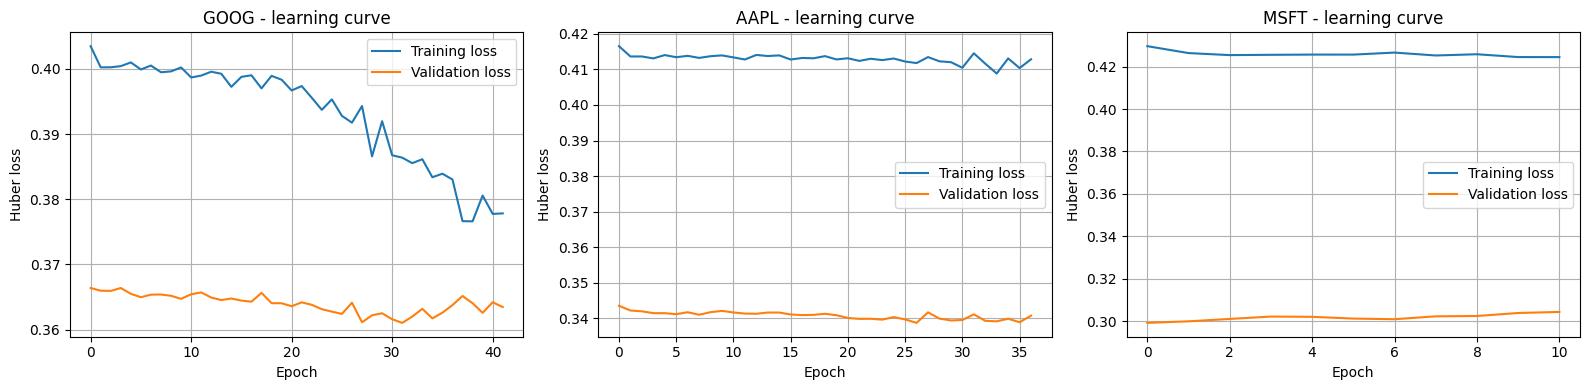


Architecture for GOOG


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,285 (161.27 KB)

 Trainable params: 13,761 (53.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,285 (161.27 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,524 (107.52 KB)

In [17]:
final_models, final_hist = {}, {}
for t in TICKERS:
    set_seed()
    p = best_params[t]
    model = build_model(p["units"], p["dropout"])
    final_hist[t] = fit_model(model, prep[t]["X_train"], prep[t]["y_train"], epochs=100, patience=10)
    model.save(f"{t}_lstm_tuned.keras")
    final_models[t] = model
    print(f"{t}: units={p['units']}, dropout={p['dropout']}, epochs run={len(final_hist[t].history['loss'])}, "
          f"best val loss={min(final_hist[t].history['val_loss']):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, t in zip(axes, TICKERS):
    ax.plot(final_hist[t].history["loss"], label="Training loss")
    ax.plot(final_hist[t].history["val_loss"], label="Validation loss")
    ax.set_title(f"{t} - learning curve")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Huber loss"); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

for t in TICKERS:
    print(f"\nArchitecture for {t}")
    final_models[t].summary()

## Task 4 - Evaluate and Improve the LSTM Models

### 4.1 How the models are evaluated
For every test day the model predicts the next-day **return** from the previous 60 real returns. We convert it to a price with `predicted price = yesterday's real close x exp(predicted return)`. This is a **one-step-ahead** prediction, the same way the model is used each day.

Metrics (all in original dollars unless stated):
- **MAE and RMSE**: average error. RMSE punishes large errors more.
- **MAPE (%)**: error as a percent of price, so the three stocks can be compared.
- **R2 (price)**: share of price variance explained. Careful: because tomorrow's price is built from today's real price, this number is high for almost any model, even a bad one. So it must not be used alone.
- **R2 (returns)**: share of return variance explained. This is the honest test of whether the model learned anything. Values near 0 (or negative) are normal for daily stock returns.
- **Directional accuracy (%)**: how often the model gets the sign of the daily move right. It should be compared with the share of up days in the test set.
- **Persistence baseline**: "tomorrow = today". If the LSTM cannot beat this simple rule, it adds little value.

In [18]:
def price_metrics(actual, pred):
    return {"MAE ($)": mean_absolute_error(actual, pred),
            "RMSE ($)": float(np.sqrt(mean_squared_error(actual, pred))),
            "MAPE (%)": float(np.mean(np.abs((actual - pred) / actual)) * 100),
            "R2 (price)": r2_score(actual, pred)}

def evaluate(model, t):
    d = prep[t]
    pred_ret = d["scaler"].inverse_transform(model.predict(d["X_test"], verbose=0)).ravel()
    true_ret = d["scaler"].inverse_transform(d["y_test"]).ravel()
    pred_price = d["test_prev_close"] * np.exp(pred_ret)
    m = price_metrics(d["test_close"], pred_price)
    m["R2 (returns)"] = r2_score(true_ret, pred_ret)
    m["Directional accuracy (%)"] = float(np.mean(np.sign(pred_ret) == np.sign(true_ret)) * 100)
    return m, pred_price, pred_ret, true_ret

results, preds = [], {}
for t in TICKERS:
    for name, model in [("Initial (64 units, dropout 0.3)", initial_models[t]), ("Tuned", final_models[t])]:
        m, pp, pr, tr = evaluate(model, t)
        results.append({"Stock": t, "Model": name, **m})
        if name == "Tuned":
            preds[t] = {"price": pp, "pred_ret": pr, "true_ret": tr}
    results.append({"Stock": t, "Model": "Persistence baseline",
                    **price_metrics(prep[t]["test_close"], prep[t]["test_prev_close"])})
    # Spread of the one-step return error on the test set, used later for forecast ranges
    prep[t]["sigma_ret"] = float(np.std(preds[t]["true_ret"] - preds[t]["pred_ret"]))

results_df = pd.DataFrame(results).set_index(["Stock", "Model"])
print("=== MODEL PERFORMANCE ON THE TEST SET ===")
display(results_df.round(4))

print("Mean error (bias) of the tuned models:")
for t in TICKERS:
    d = prep[t]
    resid_usd = d["test_close"] - preds[t]["price"]
    resid_ret = preds[t]["true_ret"] - preds[t]["pred_ret"]
    print(f"  {t}: mean price residual ${resid_usd.mean():.3f} | mean return residual {resid_ret.mean() * 100:.4f}% per day")

=== MODEL PERFORMANCE ON THE TEST SET ===


MAE ($)  RMSE ($)  MAPE (%)  \
Stock Model                                                          
GOOG  Initial (64 units, dropout 0.3)   3.2599    4.4838    1.3698   
      Tuned                             3.2540    4.4718    1.3696   
      Persistence baseline              3.2434    4.4358    1.3689   
AAPL  Initial (64 units, dropout 0.3)   2.7642    4.2939    1.2064   
      Tuned                             2.7650    4.2622    1.2068   
      Persistence baseline              2.7712    4.2747    1.2092   
MSFT  Initial (64 units, dropout 0.3)   4.8346    7.2175    1.0821   
      Tuned                             4.8377    7.2184    1.0825   
      Persistence baseline              4.8382    7.2130    1.0822   

                                       R2 (price)  R2 (returns)  \
Stock Model                                                       
GOOG  Initial (64 units, dropout 0.3)      0.9949       -0.0211   
      Tuned                                0.9949       -0.0199   
      Persistence baseline                 0.9950           NaN   
AAPL  Initial (64 units, dropout 0.3)      0.9780       -0.0064   
      Tuned                                0.9783        0.0100   
      Persistence baseline                 0.9782           NaN   
MSFT  Initial (64 units, dropout 0.3)      0.9787       -0.0007   
      Tuned                                0.9787       -0.0014   
      Persistence baseline                 0.9787           NaN   

                                       Directional accuracy (%)  
Stock Model                                                      
GOOG  Initial (64 units, dropout 0.3)                   53.7849  
      Tuned                                             53.7849  
      Persistence baseline                                  NaN  
AAPL  Initial (64 units, dropout 0.3)                   52.5896  
      Tuned                                             52.5896  
      Persistence baseline                                  NaN  
MSFT  Initial (64 units, dropout 0.3)                   51.7928  
      Tuned                                             50.9960  
      Persistence baseline                                  NaN

Mean error (bias) of the tuned models:
  GOOG: mean price residual $0.122 | mean return residual 0.0988% per day
  AAPL: mean price residual $-0.132 | mean return residual -0.0586% per day
  MSFT: mean price residual $-0.194 | mean return residual -0.0417% per day


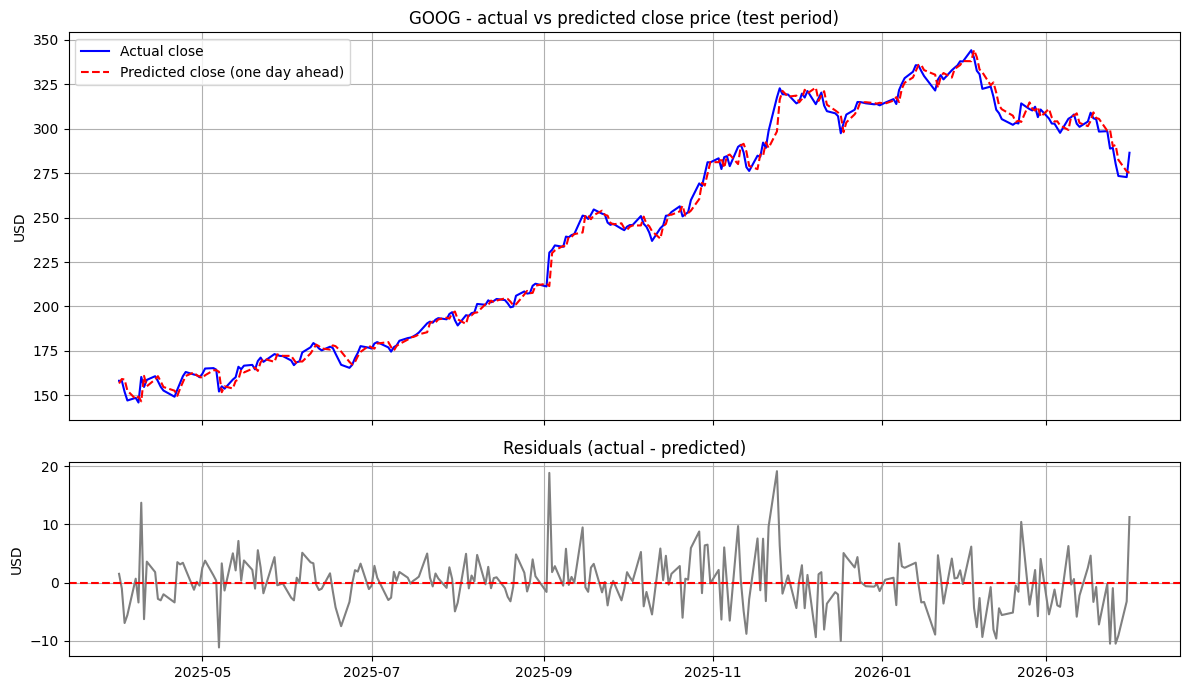

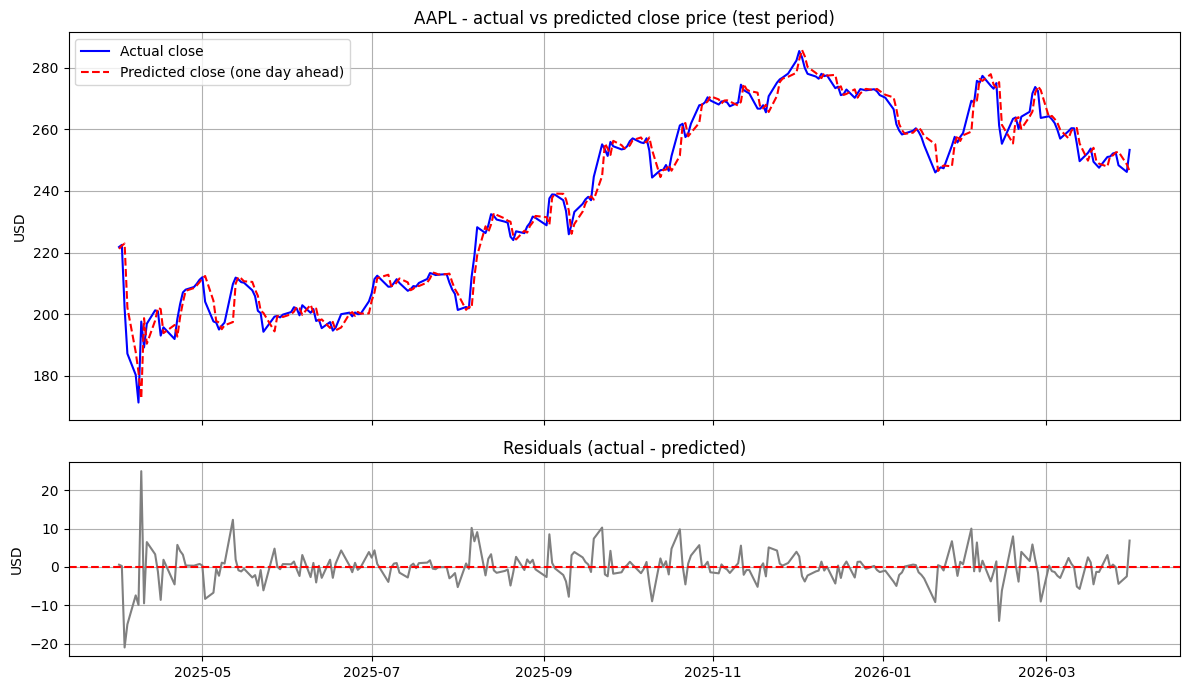

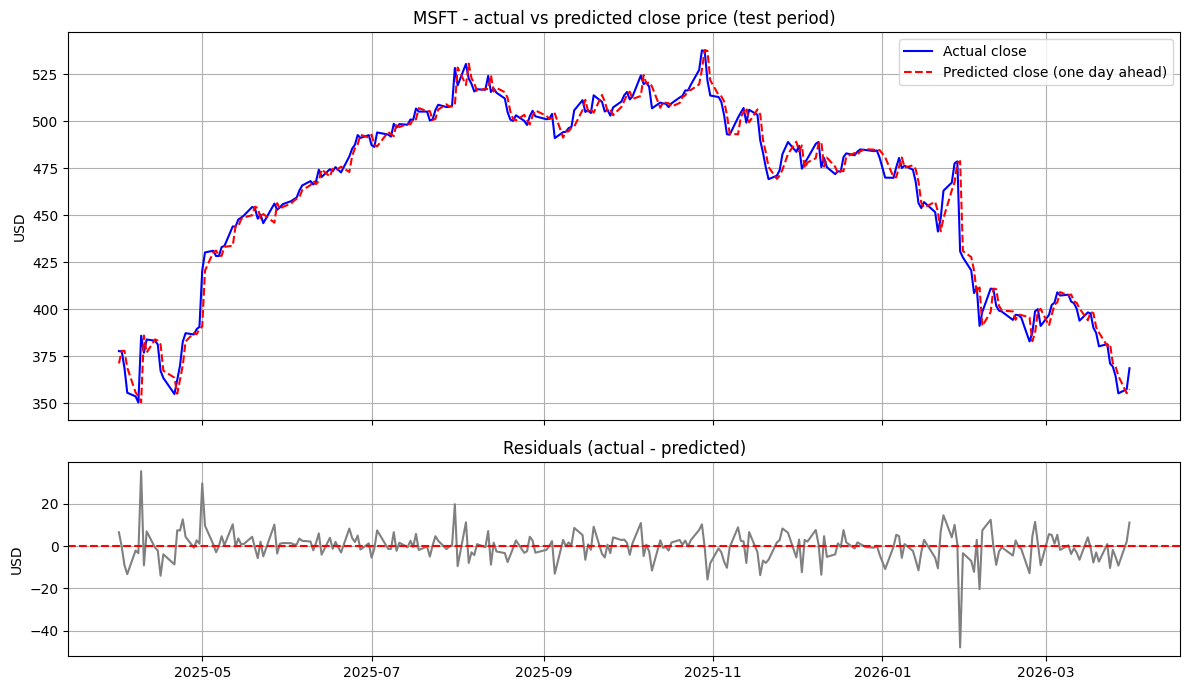

In [19]:
# Actual vs predicted prices and residuals for the tuned models
for t in TICKERS:
    d = prep[t]
    resid = d["test_close"] - preds[t]["price"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(d["test_dates"], d["test_close"], label="Actual close", color="blue")
    axes[0].plot(d["test_dates"], preds[t]["price"], label="Predicted close (one day ahead)",
                 color="red", linestyle="--")
    axes[0].set_title(f"{t} - actual vs predicted close price (test period)")
    axes[0].set_ylabel("USD"); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(d["test_dates"], resid, color="gray")
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_title("Residuals (actual - predicted)")
    axes[1].set_ylabel("USD"); axes[1].grid(True)
    plt.tight_layout(); plt.show()

In [20]:
# Plain-language summary written from the numbers above
for t in TICKERS:
    tuned = results_df.loc[(t, "Tuned")]
    base = results_df.loc[(t, "Persistence baseline")]
    init = results_df.loc[(t, "Initial (64 units, dropout 0.3)")]
    gain_base = (base["MAE ($)"] - tuned["MAE ($)"]) / base["MAE ($)"] * 100
    gain_init = (init["MAE ($)"] - tuned["MAE ($)"]) / init["MAE ($)"] * 100
    print(f"{t}: tuned MAE ${tuned['MAE ($)']:.2f} ({tuned['MAPE (%)']:.2f}% of price). "
          f"Versus the initial model: {abs(gain_init):.1f}% {'lower' if gain_init > 0 else 'higher'} MAE. "
          f"Versus persistence (${base['MAE ($)']:.2f}): {abs(gain_base):.1f}% {'better' if gain_base > 0 else 'worse'}. "
          f"Directional accuracy {tuned['Directional accuracy (%)']:.1f}% (up days in test set: {prep[t]['up_share']:.1f}%). "
          f"R2 on returns {tuned['R2 (returns)']:.3f}.")

GOOG: tuned MAE $3.25 (1.37% of price). Versus the initial model: 0.2% lower MAE. Versus persistence ($3.24): 0.3% worse. Directional accuracy 53.8% (up days in test set: 53.0%). R2 on returns -0.020.
AAPL: tuned MAE $2.76 (1.21% of price). Versus the initial model: 0.0% higher MAE. Versus persistence ($2.77): 0.2% better. Directional accuracy 52.6% (up days in test set: 52.6%). R2 on returns 0.010.
MSFT: tuned MAE $4.84 (1.08% of price). Versus the initial model: 0.1% higher MAE. Versus persistence ($4.84): 0.0% better. Directional accuracy 51.0% (up days in test set: 51.8%). R2 on returns -0.001.


### 4.2 Interpretation and improvements

- **Improvement steps made:** (1) the target was changed from price to return, because prices are non-stationary; (2) the scaler is fitted on training data only; (3) a grid search over units and dropout selected the final settings using validation data; (4) results are compared with the initial model and with the persistence baseline on the same test days.
- **Result of tuning:** the grid search showed that units and dropout matter very little. For each stock, all nine settings had validation losses within about 1.5% of each other. On the test set the tuned models are not better than the initial models, and they do not beat the persistence baseline. The main improvement in this notebook comes from the method (predicting returns, fitting the scaler on training data only, no manual bias correction), not from tuning.
- **How to read the results:** use the summary printed above. A model that beats persistence in MAE and has directional accuracy clearly above the share of up days has real predictive value. If it does not, say so in the report. Daily stock returns are very close to random, so a result near the baseline is normal and should be stated honestly.
- **No bias correction is applied.** The mean residuals printed in 4.1 show whether the models are biased. Because the models predict returns, a large systematic bias like the one seen with raw prices does not appear. Adding a hand-typed correction to forecasts would hide model problems.
- **Why evaluate in original dollars:** investors think in dollars and percent, not in standardised units.
- **Limits to mention in the report:** the model sees only past returns of one stock. It cannot know about earnings dates, news or the wider market, which are the main drivers of the big moves found in Section 2.5 and 2.6.

## Task 5 - Forecast Stock Prices for 1 to 14 May 2026

**Method (recursive forecast, no retraining):**
1. Download data up to 30 April 2026 (`end='2026-05-01'` because the end date is exclusive).
2. Take the last 60 real daily returns, scale them with the saved training scaler, and predict the next return.
3. Add the prediction to the window, drop the oldest day, and repeat. Convert each predicted return to a price starting from the real close of 30 April.
4. The forecast dates are the **10 trading days** from 1 May to 14 May 2026.

The saved tuned models are loaded as they are. They are **not** trained again.

Forecast range: the recursive method makes errors grow over time, so we also show an approximate 80% range, `price x exp(+/- 1.28 x sigma x sqrt(h))`, where sigma is the one-day return error on the test set and h is the number of days ahead.

In [21]:
FORECAST_DATES = pd.bdate_range("2026-05-01", "2026-05-14")   # 10 trading days
H = len(FORECAST_DATES)
Z80 = 1.28
print(f"Forecast horizon: {H} trading days, {FORECAST_DATES[0].date()} to {FORECAST_DATES[-1].date()}")

forecast, lower, upper, recent = {}, {}, {}, {}
last_info = {}
for t in TICKERS:
    model = load_model(f"{t}_lstm_tuned.keras")      # trained model, NOT updated
    scaler = joblib.load(f"{t}_scaler.pkl")          # scaler fitted on the training period

    df = download(t, START_DATE, "2026-05-01")       # includes 30 April 2026
    close = df["Close"]
    if close.index[-1] != pd.Timestamp("2026-04-30"):
        print(f"WARNING {t}: last available date is {close.index[-1].date()}, expected 2026-04-30")
    rets = np.log(close / close.shift(1)).dropna()

    window = scaler.transform(rets.values[-SEQ_LEN:].reshape(-1, 1)).reshape(1, SEQ_LEN, 1)
    price = float(close.iloc[-1])
    last_info[t] = (close.index[-1].date(), price)

    path = []
    for _ in range(H):
        r_scaled = model.predict(window, verbose=0)               # next-day scaled return
        r = float(scaler.inverse_transform(r_scaled)[0, 0])
        price = price * np.exp(r)
        path.append(price)
        window = np.concatenate([window[:, 1:, :], r_scaled.reshape(1, 1, 1)], axis=1)

    path = np.array(path)
    sd = prep[t]["sigma_ret"] * np.sqrt(np.arange(1, H + 1))
    forecast[t] = path
    lower[t] = path * np.exp(-Z80 * sd)
    upper[t] = path * np.exp(Z80 * sd)
    recent[t] = close.tail(60)

output_df = pd.DataFrame(forecast, index=FORECAST_DATES)
output_df.index.name = "Date"
output_df.to_csv("Output.csv")

range_df = pd.concat({"Forecast": output_df,
                      "Low (80%)": pd.DataFrame(lower, index=FORECAST_DATES),
                      "High (80%)": pd.DataFrame(upper, index=FORECAST_DATES)}, axis=1)
range_df.index.name = "Date"
range_df.to_csv("Forecast_with_range.csv")

print("Saved Output.csv and Forecast_with_range.csv")
display(output_df.round(2))

Forecast horizon: 10 trading days, 2026-05-01 to 2026-05-14
Saved Output.csv and Forecast_with_range.csv


,GOOG,AAPL,MSFT
Date,,,
2026-05-01,375.02,271.10,406.36
2026-05-04,369.04,271.32,406.60
2026-05-05,363.94,271.54,406.83
2026-05-06,360.30,271.76,407.05
2026-05-07,358.79,271.97,407.24
2026-05-08,359.56,272.18,407.43
2026-05-11,361.50,272.38,407.60
2026-05-12,363.35,272.58,407.78
2026-05-13,364.11,272.78,407.96


In [22]:
# Check the output file before submitting
chk = pd.read_csv("Output.csv", index_col="Date", parse_dates=True)
assert chk.shape == (10, 3), chk.shape
assert chk.index.min() == pd.Timestamp("2026-05-01") and chk.index.max() == pd.Timestamp("2026-05-14")
assert not chk.isna().any().any()
print("Output.csv OK:", chk.shape[0], "rows,", list(chk.columns), "columns")

# Summary table for the report
summary = []
for t in TICKERS:
    d0, p0 = last_info[t]
    summary.append({"Stock": t, f"Last close ({d0})": round(p0, 2),
                    "Forecast 1 May": round(output_df[t].iloc[0], 2),
                    "Forecast 14 May": round(output_df[t].iloc[-1], 2),
                    "Change to 14 May (%)": round((output_df[t].iloc[-1] / p0 - 1) * 100, 2),
                    "80% range on 14 May": f"{lower[t][-1]:.2f} to {upper[t][-1]:.2f}"})
display(pd.DataFrame(summary))

Output.csv OK: 10 rows, ['GOOG', 'AAPL', 'MSFT'] columns


,Stock,Last close (2026-04-30),Forecast 1 May,Forecast 14 May,Change to 14 May (%),80% range on 14 May
0,GOOG,381.46,375.02,363.44,-4.72,336.61 to 392.42
1,AAPL,270.87,271.10,272.97,0.78,252.16 to 295.50
2,MSFT,406.13,406.36,408.13,0.49,381.52 to 436.59


In [23]:
# Forecast charts: last 60 real days + forecast + approximate 80% range
fig = make_subplots(rows=3, cols=1, subplot_titles=TICKERS, vertical_spacing=0.08)
for i, t in enumerate(TICKERS, start=1):
    fig.add_trace(go.Scatter(x=recent[t].index, y=recent[t], mode="lines", name=f"{t} actual",
                             line=dict(color="black")), row=i, col=1)
    fig.add_trace(go.Scatter(x=list(FORECAST_DATES) + list(FORECAST_DATES[::-1]),
                             y=list(upper[t]) + list(lower[t][::-1]), fill="toself",
                             fillcolor="rgba(0,100,255,0.15)", line=dict(width=0),
                             name=f"{t} 80% range", hoverinfo="skip"), row=i, col=1)
    fig.add_trace(go.Scatter(x=FORECAST_DATES, y=output_df[t], mode="lines+markers",
                             name=f"{t} forecast", line=dict(color="blue")), row=i, col=1)
fig.update_layout(title="LSTM blind forecast, 1 to 14 May 2026", height=950, hovermode="x unified")
fig.show()

### Forecast notes
- The forecast starts from the real close of 30 April 2026, so there is no artificial jump on the first day.
- A model trained on past returns only predicts small, smooth moves. Recursive forecasts tend to move toward the average historical return, so the forecast lines are gentle. They are **not** a prediction of earnings reactions or news.
- The 80% range is wide compared with the forecast move. If the range covers the last close, the forecast direction is weak evidence. In the Section 02 report, use the forecast together with the April price trend and news, and describe the recommendation as short-term and uncertain.

### Optional check after 14 May 2026 (not used for training)
Run this cell only when the real May prices are available. It compares the saved forecast with real prices. The models are not changed.

In [24]:
try:
    rows = []
    for t in TICKERS:
        actual = download(t, "2026-05-01", "2026-05-15")["Close"]
        pred = output_df[t].reindex(actual.index)
        if actual.empty:
            print(f"{t}: no May data available yet")
            continue
        rows.append({"Stock": t, "Days compared": len(actual),
                     "MAE ($)": round(mean_absolute_error(actual, pred), 2),
                     "MAPE (%)": round(float(np.mean(np.abs((actual - pred) / actual))) * 100, 2),
                     "Last-day error (%)": round((pred.iloc[-1] / actual.iloc[-1] - 1) * 100, 2),
                     "Actual inside 80% range (%)": round(float(np.mean(
                         (actual.values >= pd.DataFrame(lower, index=FORECAST_DATES)[t].reindex(actual.index).values) &
                         (actual.values <= pd.DataFrame(upper, index=FORECAST_DATES)[t].reindex(actual.index).values))) * 100, 0)})
    display(pd.DataFrame(rows))
except Exception as e:
    print("Could not compare with real prices:", e)

,Stock,Days compared,MAE ($),MAPE (%),Last-day error (%),Actual inside 80% range (%)
0,GOOG,10,25.75,6.57,-8.38,30.0
1,AAPL,10,16.93,5.81,-8.38,20.0
2,MSFT,10,4.75,1.15,0.09,100.0


### Result of the May check
This check was run after 14 May 2026. The forecast itself was made with data up to 30 April and the models were not changed.

- MSFT: the forecast stayed close to the real prices and all days were inside the 80% range.
- GOOG and AAPL: real prices rose well above the forecast, and most days were outside the 80% range. Both companies reported earnings around 29 to 30 April, and the model only reads past returns, so it cannot anticipate an earnings reaction.
- Conclusion: the LSTM output should be treated as a weak, short-term signal. It is not a reliable basis for buy or sell decisions on its own.